In [26]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

from boxe_utils import (
    DEFAULT_VIDEOS,
    load_video,
    add_velocity_and_acceleration,
    build_label_mapping_from_videos,
)

/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 30 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Modelo carregado: <Functional name=functional, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step
=== TESTE REAL (V9/V10 nunca vistos no treino) ===
               precision    recall  f1-score   support

        Cross       0.97      0.95      0.96        63
          Jab       0.95      0.99      0.97        80
    Lead Hook       1.00      0.93      0.97        46
Lead Uppercut       1.00      0.97      0.99        35
    Rear Hook       0.89      1.00      0.94        17
Rear Uppercut       1.00      1.00      1.00        60

     accuracy                           0.97       301
    macro avg       0.97      0.97      0.97       301
 weighted avg       0.97      0.97      0.97       301



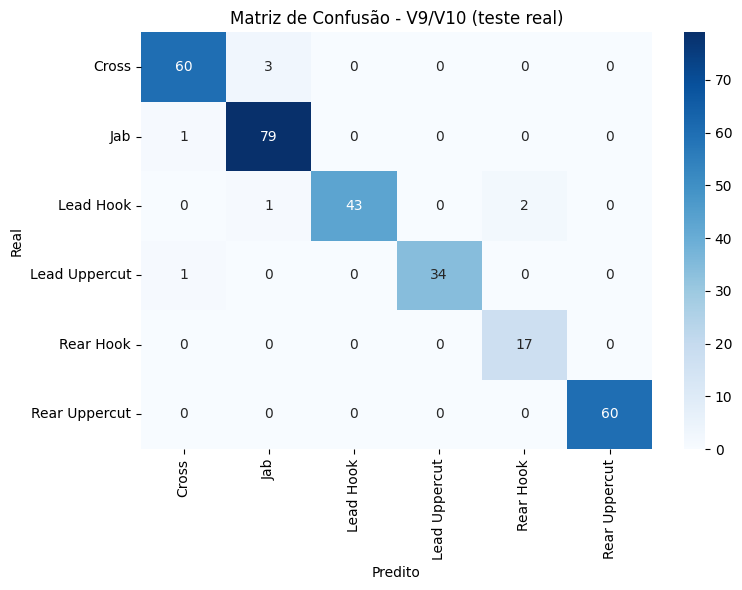

In [27]:
classes, label_to_id, _ = build_label_mapping_from_videos(DEFAULT_VIDEOS)

X_real_test, y_real_test = [], []

for video in ["V9", "V10"]:
    skeleton, labels_raw = load_video(video)
    y_raw = np.array([label_to_id[x] for x in labels_raw])
    X_reshaped = skeleton.reshape(-1, 25, 34)
    X_real_test.append(X_reshaped)
    y_real_test.append(y_raw)

X_real_test = np.concatenate(X_real_test)
y_real_test = np.concatenate(y_real_test)

# Normalizar com stats do treino (idealmente carregue X_mean_global e X_std_global salvos)
X_mean_global = X_real_test.mean()
X_std_global = X_real_test.std() + 1e-8

X_real_norm = (X_real_test - X_mean_global) / X_std_global
X_real_feat = add_velocity_and_acceleration(X_real_norm)

model = load_model("modelo_boxe.keras")
print("Modelo carregado:", model)

y_pred_real = np.argmax(model.predict(X_real_feat), axis=1)
print("=== TESTE REAL (V9/V10 nunca vistos no treino) ===")
print(classification_report(y_real_test, y_pred_real, target_names=classes))

cm = confusion_matrix(y_real_test, y_pred_real)
fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.title('Matriz de Confusão - V9/V10 (teste real)')
plt.tight_layout()
fig.savefig("matrix.png", bbox_inches="tight")
plt.show()
plt.close(fig)